In [1]:
#Installing dependencies
!pip install datasets
!pip install torch torchvision
!pip install scikit-learn
!pip install seaborn
!pip install matplotlib
!pip install opencv-python

In [2]:
#Loading required libraries
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from PIL import Image
import cv2

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    multilabel_confusion_matrix,
    roc_curve
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
#Loading dataset
from datasets import load_dataset

ds = load_dataset("tempawefwf/Brain_Tumor_MRI_Dataset")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Brain Tumor MRI.zip:   0%|          | 0.00/156M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7023 [00:00<?, ? examples/s]

In [4]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 7023
    })
})


In [5]:
# Splitting into train and test
data = ds["train"]

split = data.train_test_split(test_size=0.2, seed=42)

train_ds = split["train"]
test_ds = split["test"]

print(train_ds)
print(test_ds)

Dataset({
    features: ['image', 'label'],
    num_rows: 5618
})
Dataset({
    features: ['image', 'label'],
    num_rows: 1405
})


In [6]:
#Labels
labels = train_ds.features["label"].names
num_classes = len(labels)

print(labels)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [7]:
#Converting to Multi-Label
def convert_multilabel(label):

    vec = np.zeros(num_classes)
    vec[label] = 1

    return vec

In [8]:
#Image Preprocessing
transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [9]:
#Data set loader
class MRIDataset(Dataset):

    def __init__(self, hf_dataset, transform=None):

        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        item = self.dataset[idx]

        image = item["image"]
        label = item["label"]

        image = image.convert("RGB")

        label_vec = convert_multilabel(label)

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label_vec).float()

In [10]:
#DataLoaders
train_dataset = MRIDataset(train_ds, transform)
test_dataset = MRIDataset(test_ds, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

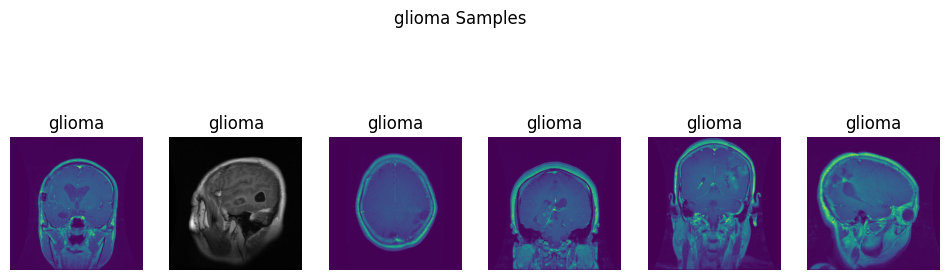

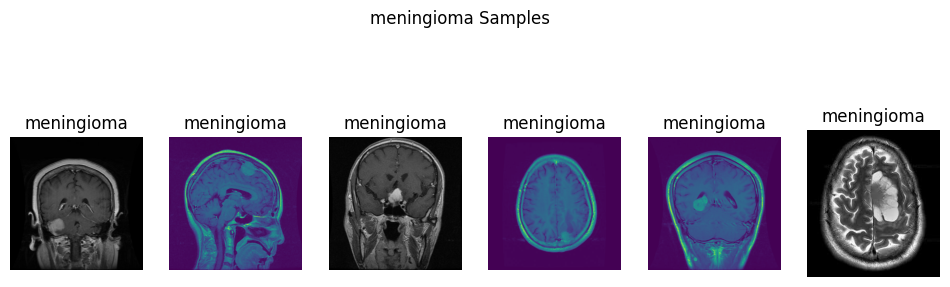

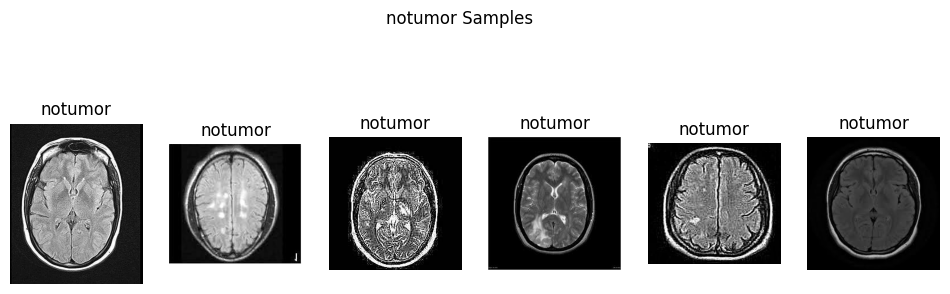

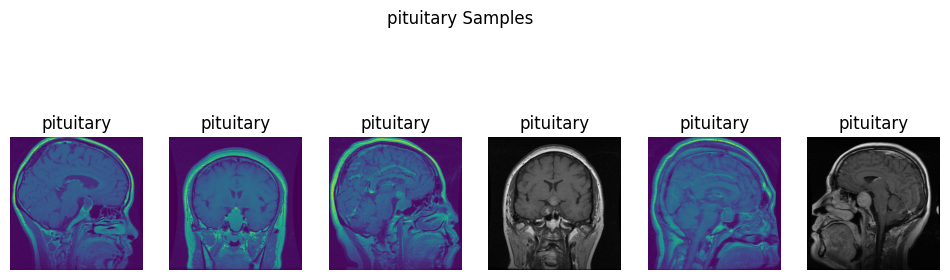

In [27]:
def show_images_per_class(dataset, labels, num_images=6):

    for label_id, label_name in enumerate(labels):

        plt.figure(figsize=(12,4))
        count = 0

        for i in range(len(dataset)):

            if dataset[i]["label"] == label_id:

                img = dataset[i]["image"]

                plt.subplot(1, num_images, count+1)
                plt.imshow(img)
                plt.title(label_name)
                plt.axis("off")

                count += 1

                if count == num_images:
                    break

        plt.suptitle(f"{label_name} Samples")
        plt.show()


show_images_per_class(train_ds, labels)

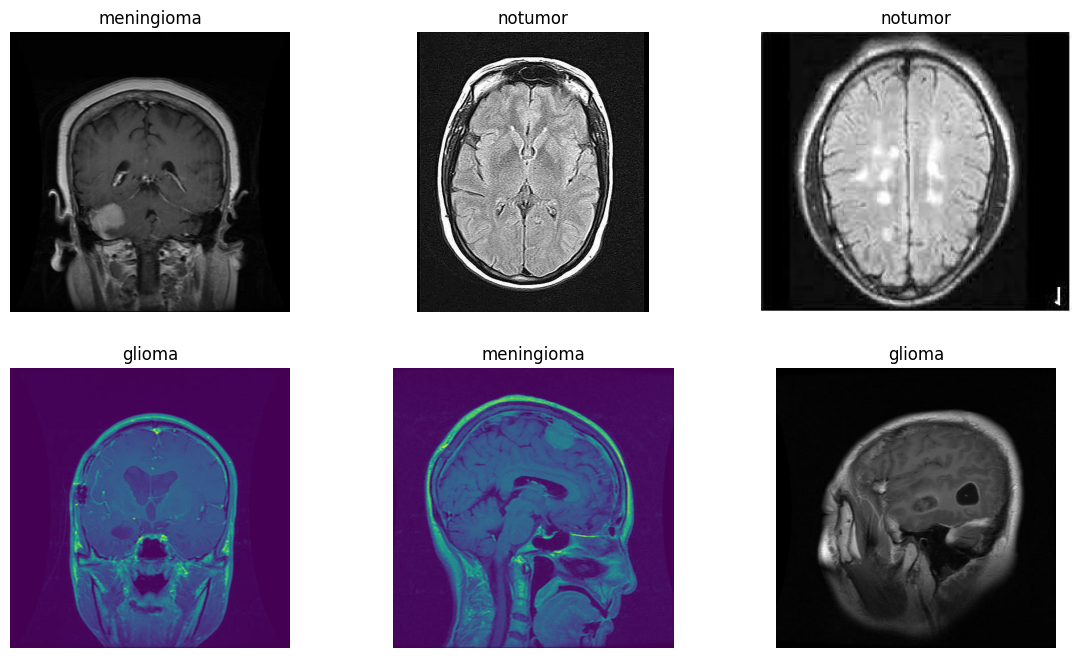

In [11]:
#MRI Images
plt.figure(figsize=(14,8))

for i in range(6):

    img = train_ds[i]["image"]
    label = labels[train_ds[i]["label"]]

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

plt.show()

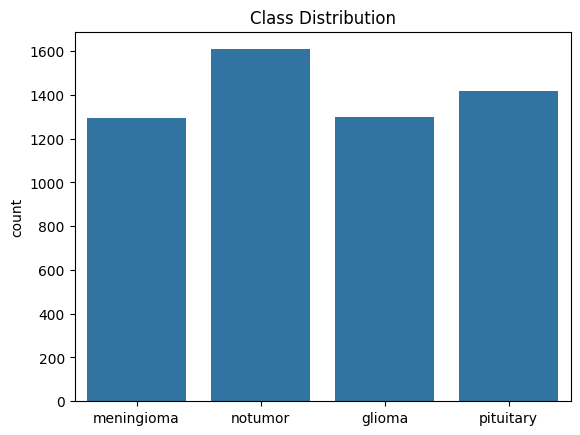

In [12]:
#Class Distribution
labels_list=[train_ds[i]["label"] for i in range(len(train_ds))]
labels_text=[labels[i] for i in labels_list]

sns.countplot(x=labels_text)
plt.title("Class Distribution")
plt.show()

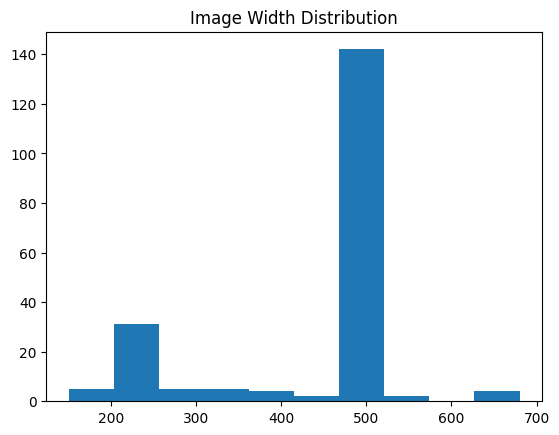

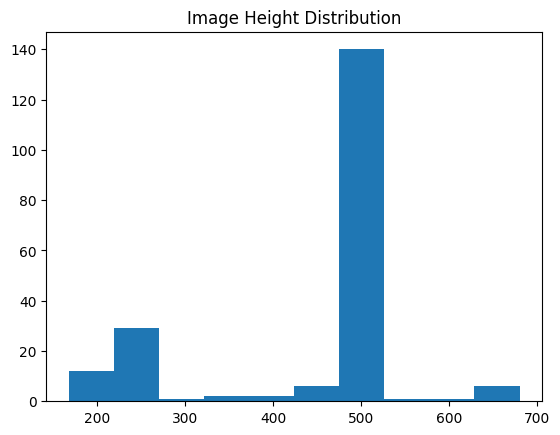

In [13]:
widths=[]
heights=[]

for i in range(200):

    img = train_ds[i]["image"]

    w,h = img.size

    widths.append(w)
    heights.append(h)

plt.hist(widths)
plt.title("Image Width Distribution")
plt.show()

plt.hist(heights)
plt.title("Image Height Distribution")
plt.show()

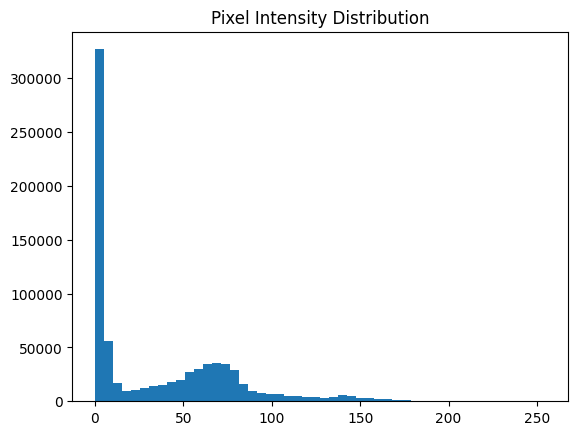

In [14]:
#Pixel Intensity Distribution
img = np.array(train_ds[0]["image"])

plt.hist(img.ravel(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.show()

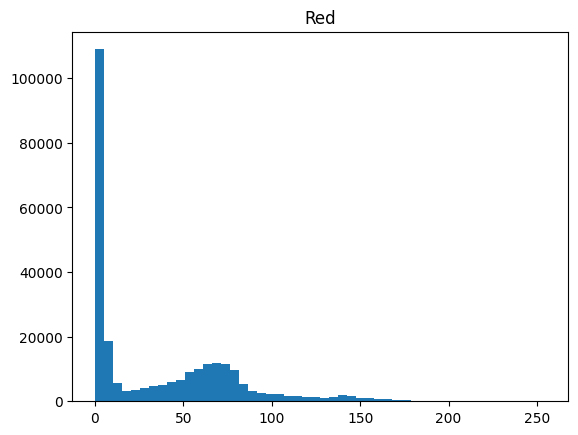

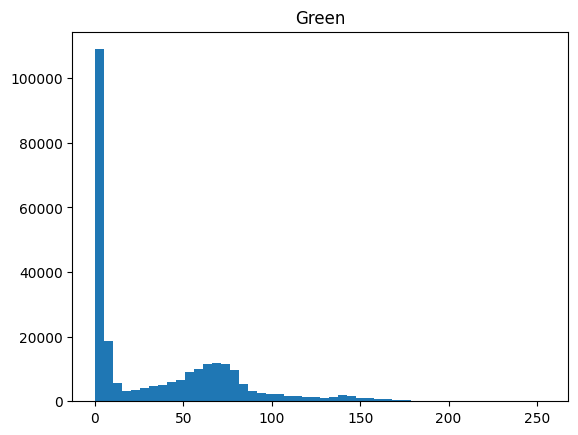

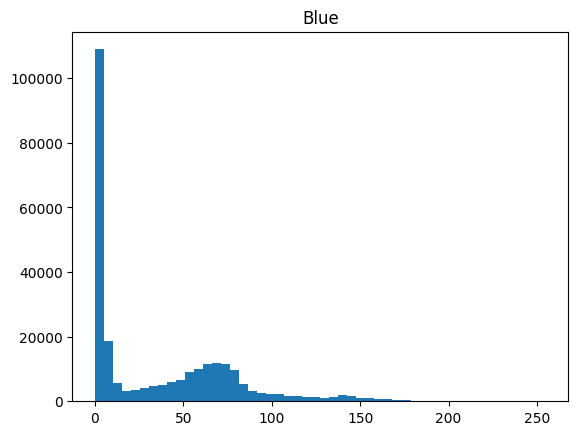

In [15]:
#RGB Channel Distribution
for i,c in enumerate(["Red","Green","Blue"]):

    plt.hist(img[:,:,i].ravel(),bins=50)
    plt.title(c)
    plt.show()

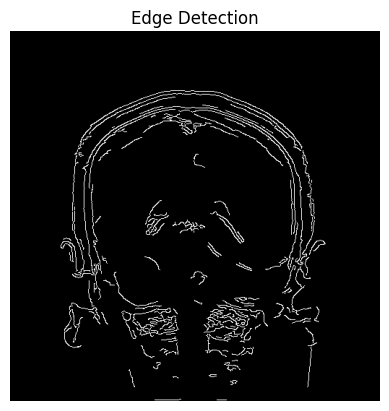

In [16]:
#Edge Detection
gray=cv2.cvtColor(img,cv2.COLOR_RGB2GRAY)
edges=cv2.Canny(gray,100,200)

plt.imshow(edges,cmap="gray")
plt.title("Edge Detection")
plt.axis("off")
plt.show()

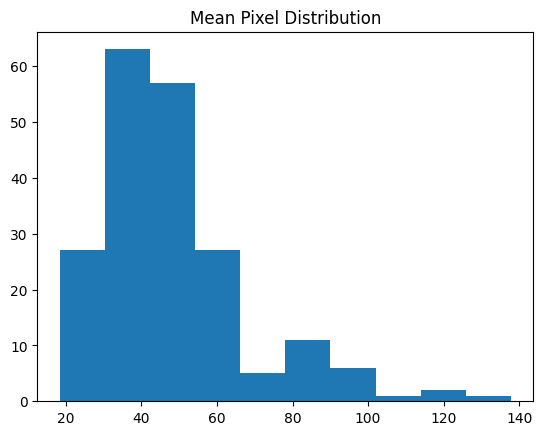

In [17]:
#Mean Pixel Distribution
means=[np.array(train_ds[i]["image"]).mean() for i in range(200)]

plt.hist(means)
plt.title("Mean Pixel Distribution")
plt.show()

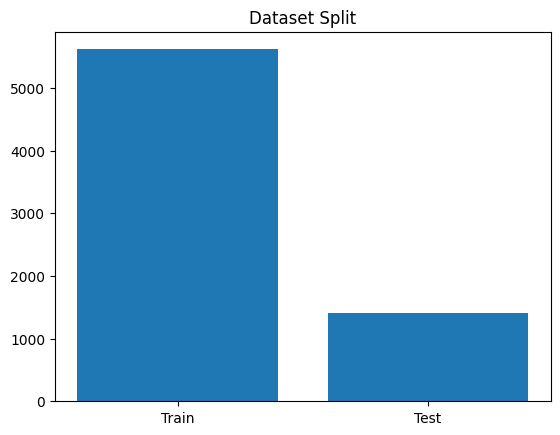

In [18]:
#Train vs Test Split
sizes=[len(train_ds),len(test_ds)]

plt.bar(["Train","Test"],sizes)
plt.title("Dataset Split")
plt.show()

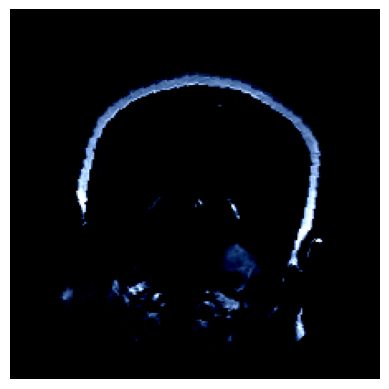

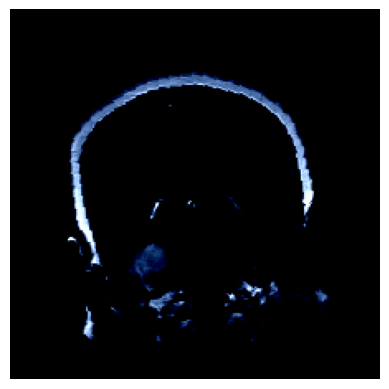

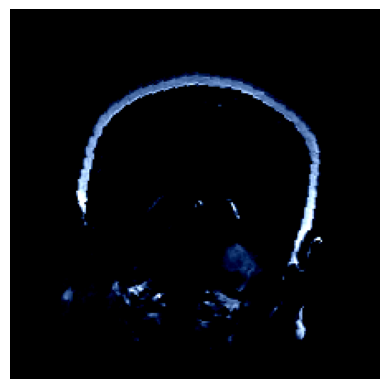

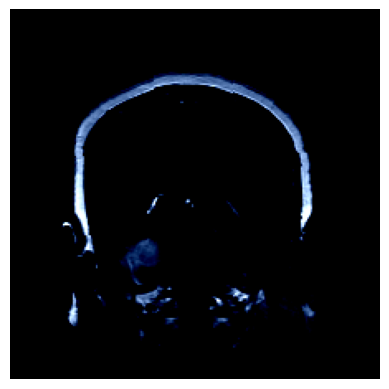

In [19]:
#Augmented Images
img=train_ds[0]["image"]

for i in range(4):

    aug=transform(img)
    aug=aug.permute(1,2,0)

    plt.imshow(aug)
    plt.axis("off")
    plt.show()

In [20]:
#CNN
class CustomCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(

            nn.Flatten(),
            nn.Linear(128*28*28,256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256,num_classes)
        )

    def forward(self,x):

        x=self.conv(x)
        x=self.fc(x)

        return x

In [21]:
#Transfer Learning
def get_resnet():

    model=models.resnet50(pretrained=True)

    model.fc=nn.Linear(model.fc.in_features,num_classes)

    return model


def get_densenet():

    model=models.densenet121(pretrained=True)

    model.classifier=nn.Linear(model.classifier.in_features,num_classes)

    return model


def get_efficientnet():

    model=models.efficientnet_b0(pretrained=True)

    model.classifier[1]=nn.Linear(
        model.classifier[1].in_features,
        num_classes
    )

    return model

In [22]:
#Training Function
def train_model(model,epochs=5):

    model=model.to(device)

    criterion=nn.BCEWithLogitsLoss()

    optimizer=optim.Adam(model.parameters(),lr=0.0001)

    for epoch in range(epochs):

        model.train()

        total_loss=0

        for images,labels in train_loader:

            images=images.to(device)
            labels=labels.to(device)

            optimizer.zero_grad()

            outputs=model(images)

            loss=criterion(outputs,labels)

            loss.backward()

            optimizer.step()

            total_loss+=loss.item()

        print("Epoch",epoch+1,"Loss",total_loss)

    return model

In [23]:
#Evaluation
def evaluate_model(model):

    model.eval()

    preds=[]
    trues=[]

    with torch.no_grad():

        for images,labels in test_loader:

            images=images.to(device)

            outputs=model(images)

            outputs=torch.sigmoid(outputs)

            preds.append(outputs.cpu().numpy())
            trues.append(labels.numpy())

    preds=np.vstack(preds)
    trues=np.vstack(trues)

    preds_binary=(preds>0.5).astype(int)

    acc=accuracy_score(trues,preds_binary)
    prec=precision_score(trues,preds_binary,average="micro")
    rec=recall_score(trues,preds_binary,average="micro")
    f1=f1_score(trues,preds_binary,average="micro")
    roc=roc_auc_score(trues,preds)

    print("Accuracy:",acc)
    print("Precision:",prec)
    print("Recall:",rec)
    print("F1 Score:",f1)
    print("ROC AUC:",roc)

    return acc,prec,rec,f1,roc

In [24]:
# Initialize models
cnn=train_model(CustomCNN())
resnet=train_model(get_resnet())
densenet=train_model(get_densenet())
efficient=train_model(get_efficientnet())

Epoch 1 Loss 60.43200781941414
Epoch 2 Loss 40.27699784189463
Epoch 3 Loss 32.70964828878641
Epoch 4 Loss 27.816501274704933
Epoch 5 Loss 24.18877261132002


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 209MB/s]


Epoch 1 Loss 20.03317675832659
Epoch 2 Loss 7.179332492873073
Epoch 3 Loss 4.770691345911473
Epoch 4 Loss 3.905006860732101
Epoch 5 Loss 2.8671124040847644
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


...

Epoch 1 Loss 25.995284397155046
Epoch 2 Loss 9.647513095289469
Epoch 3 Loss 5.09834915259853
Epoch 4 Loss 3.771077865269035


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 5 Loss 2.90369123313576
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 142MB/s]


Epoch 1 Loss 42.600345224142075
Epoch 2 Loss 11.99811099562794
Epoch 3 Loss 6.997707657050341
Epoch 4 Loss 4.841305855894461
Epoch 5 Loss 3.888714203145355


In [25]:
cnn_metrics=evaluate_model(cnn)
resnet_metrics=evaluate_model(resnet)
densenet_metrics=evaluate_model(densenet)
efficient_metrics=evaluate_model(efficient)

Accuracy: 0.8540925266903915
Precision: 0.8987435328898744
Recall: 0.8654804270462634
F1 Score: 0.8817984046410442
ROC AUC: 0.9807493907636993
Accuracy: 0.9743772241992883
Precision: 0.9800285306704708
Recall: 0.9779359430604982
F1 Score: 0.9789811186319914
ROC AUC: 0.9994779836446303
Accuracy: 0.9829181494661922
Precision: 0.9885877318116976
Recall: 0.9864768683274021
F1 Score: 0.9875311720698254
ROC AUC: 0.999013749178905
Accuracy: 0.9857651245551602
Precision: 0.9885958660014256
Recall: 0.9871886120996441
F1 Score: 0.9878917378917379
ROC AUC: 0.9997655098797161


In [26]:
results=pd.DataFrame({

"Model":[
"Custom CNN",
"ResNet50",
"DenseNet121",
"EfficientNetB0"
],

"Accuracy":[
cnn_metrics[0],
resnet_metrics[0],
densenet_metrics[0],
efficient_metrics[0]
],

"Precision":[
cnn_metrics[1],
resnet_metrics[1],
densenet_metrics[1],
efficient_metrics[1]
],

"Recall":[
cnn_metrics[2],
resnet_metrics[2],
densenet_metrics[2],
efficient_metrics[2]
],

"F1 Score":[
cnn_metrics[3],
resnet_metrics[3],
densenet_metrics[3],
efficient_metrics[3]
],

"ROC AUC":[
cnn_metrics[4],
resnet_metrics[4],
densenet_metrics[4],
efficient_metrics[4]
]

})

print(results)

            Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0      Custom CNN  0.854093   0.898744  0.865480  0.881798  0.980749
1        ResNet50  0.974377   0.980029  0.977936  0.978981  0.999478
2     DenseNet121  0.982918   0.988588  0.986477  0.987531  0.999014
3  EfficientNetB0  0.985765   0.988596  0.987189  0.987892  0.999766


In [31]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model):

    model.eval()

    preds=[]
    trues=[]

    with torch.no_grad():

        for images,labels_batch in test_loader:

            images=images.to(device)

            outputs=model(images)

            preds.extend(torch.argmax(outputs,1).cpu().numpy())
            trues.extend(torch.argmax(labels_batch,1).numpy())

    cm=confusion_matrix(trues,preds)

    plt.figure(figsize=(14,8))
    sns.heatmap(cm,annot=True,fmt="d",
                xticklabels=labels,
                yticklabels=labels)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

CNN Confusion Matrix


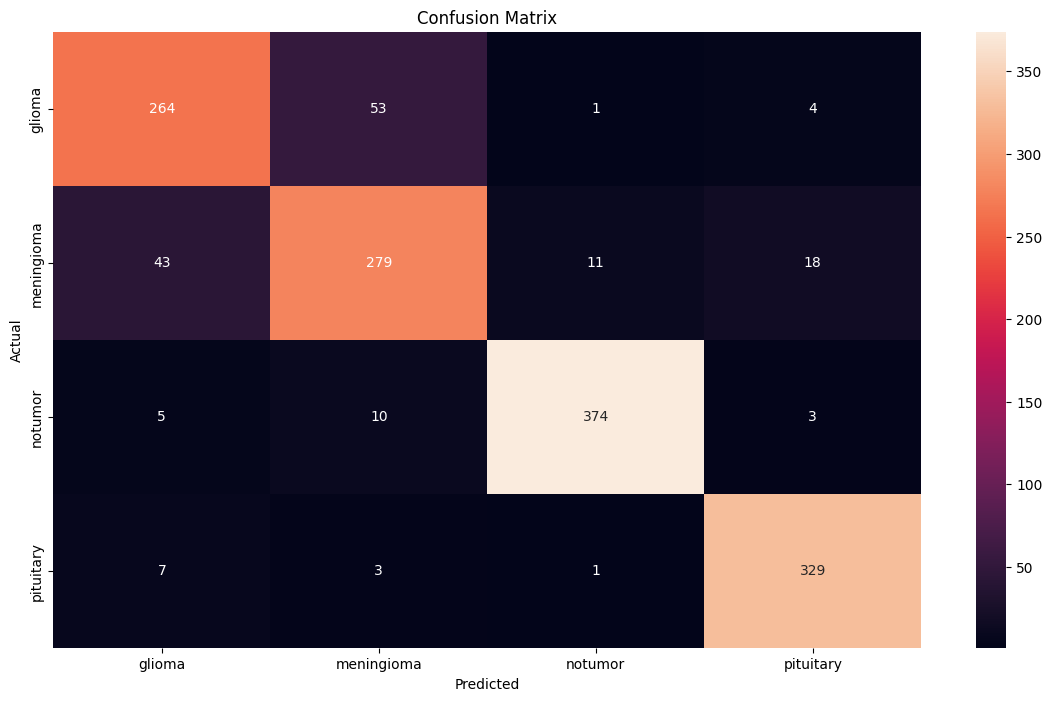

In [32]:
print("CNN Confusion Matrix")
plot_confusion_matrix(cnn)

ResNet50 Confusion Matrix


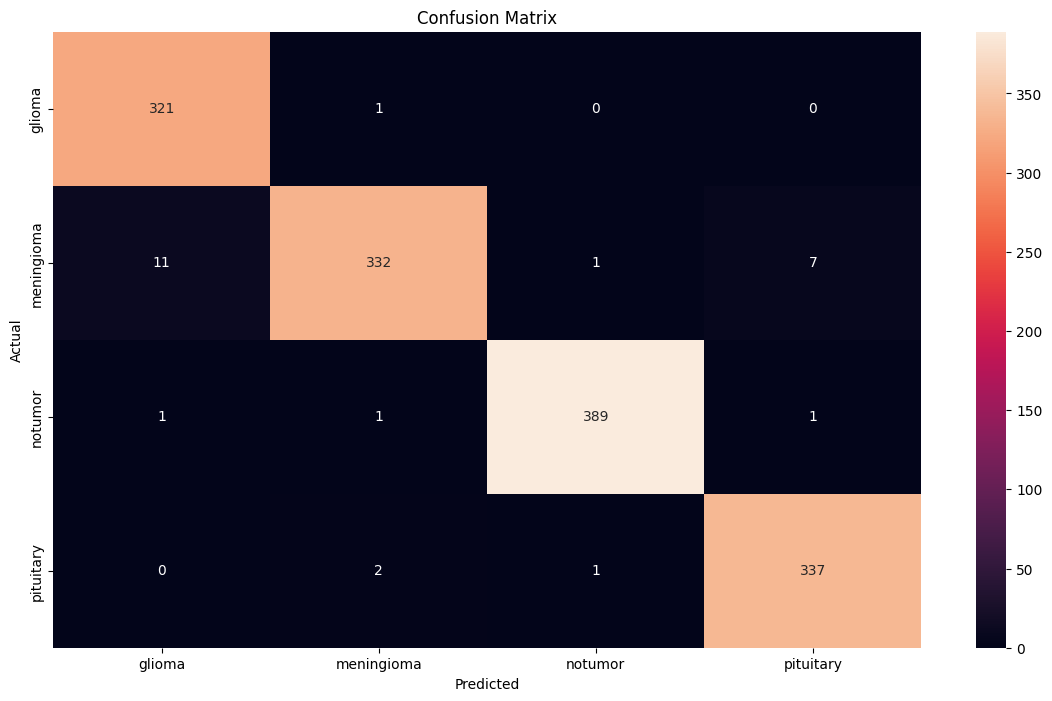

In [33]:
print("ResNet50 Confusion Matrix")
plot_confusion_matrix(resnet)

DenseNet121 Confusion Matrix


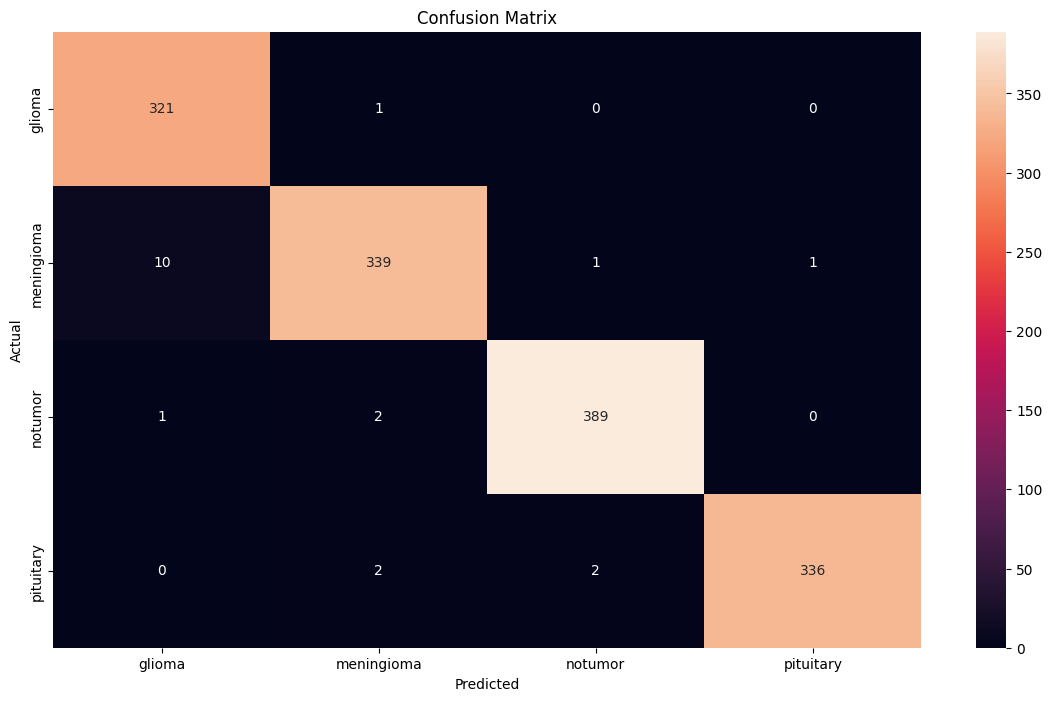

In [34]:
print("DenseNet121 Confusion Matrix")
plot_confusion_matrix(densenet)


EfficientNet Confusion Matrix


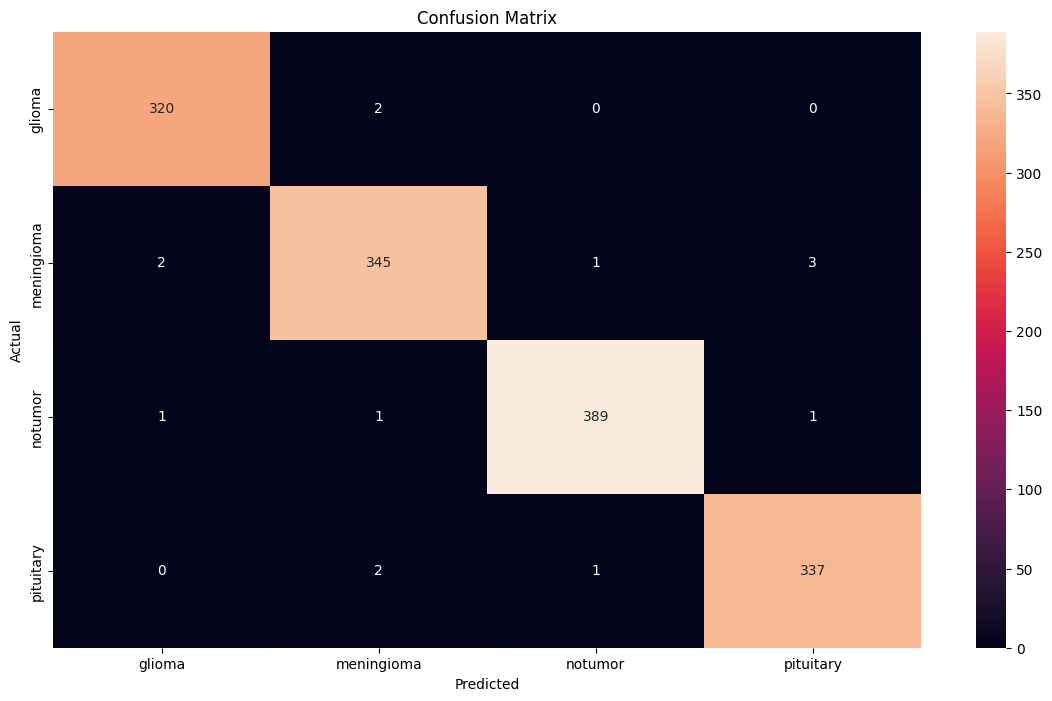

In [35]:

print("EfficientNet Confusion Matrix")
plot_confusion_matrix(efficient)

In [36]:
#ROC Curve Per Class
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def plot_roc_per_class(model):

    model.eval()

    preds=[]
    trues=[]

    with torch.no_grad():

        for images,labels_batch in test_loader:

            images=images.to(device)

            outputs=model(images)

            outputs=torch.sigmoid(outputs)

            preds.append(outputs.cpu().numpy())
            trues.append(labels_batch.numpy())

    preds=np.vstack(preds)
    trues=np.vstack(trues)

    for i,label in enumerate(labels):

        fpr,tpr,_=roc_curve(trues[:,i],preds[:,i])

        roc_auc=auc(fpr,tpr)

        plt.plot(fpr,tpr,label=f"{label} AUC={roc_auc:.2f}")

    plt.plot([0,1],[0,1],'k--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title("ROC Curve per Class")

    plt.legend()

    plt.show()

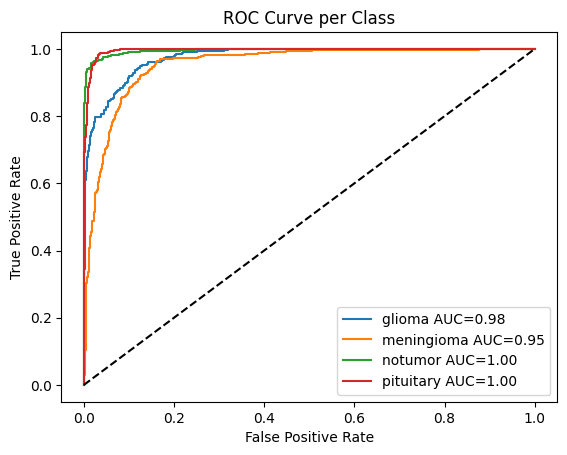

In [37]:
plot_roc_per_class(cnn)

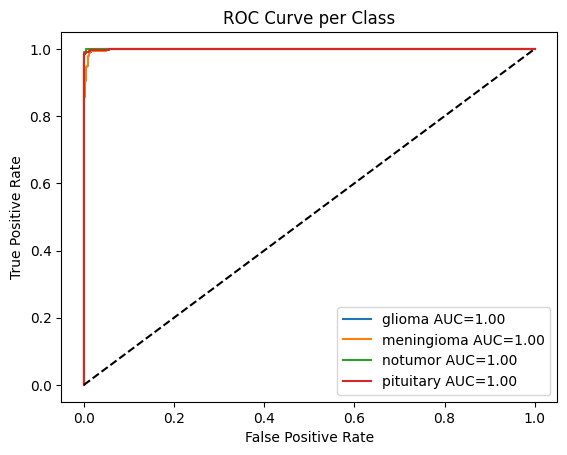

In [38]:
plot_roc_per_class(resnet)

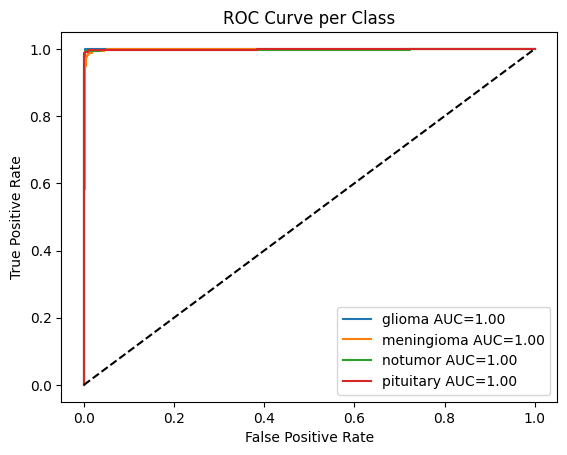

In [39]:
plot_roc_per_class(densenet)

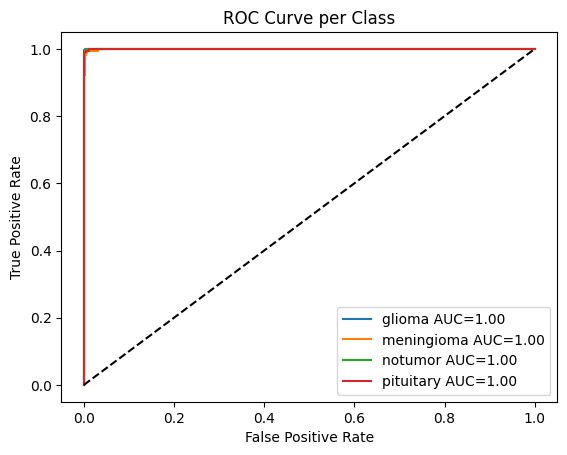

In [40]:
plot_roc_per_class(efficient)